<a href="https://colab.research.google.com/github/soumensen411/Machine_Learning_Models_Walkthroughs/blob/main/Linear%20Regression/Linear_regression_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Create a simple dataset

In [88]:
data = {
    "StudyHours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "ExamScore": [35, 40, 50, 55, 65, 70, 75, 85, 90, 95]
}
df = pd.DataFrame(data)
df.head()

,StudyHours,ExamScore
0,1,35
1,2,40
2,3,50
3,4,55
4,5,65


# Visualize the data

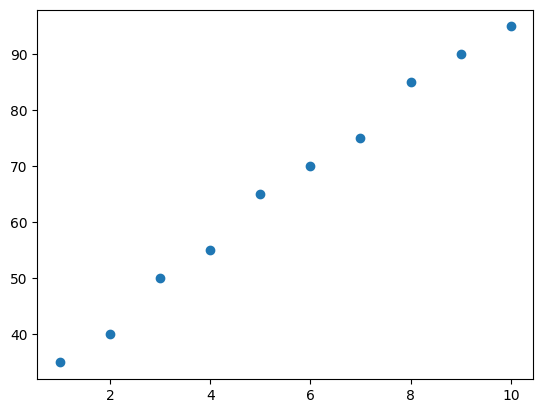

In [89]:
plt.scatter(df['StudyHours'],df['ExamScore'])

# Apply SKlearn Linear regression Model

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df.drop(columns = ['ExamScore'])
y = df['ExamScore']
model = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [91]:
model.fit(X_train,y_train)

LinearRegression()

In [92]:
y_pred = model.predict(X_test)

In [93]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 3.86
R-squared: 0.99


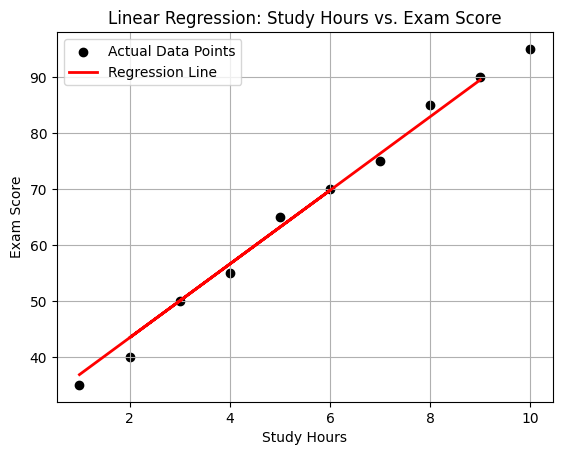

In [94]:
plt.scatter(df['StudyHours'], df['ExamScore'], color='black', label='Actual Data Points')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Study Hours vs. Exam Score')
plt.grid(True)
plt.legend()
plt.show()

# Implement Linear Regression Model from scratch

In [100]:
def loss_function(m,b,df):
  total_error = 0
  for i in range(len(df)):
    x = df.iloc[i].StudyHours
    y = df.iloc[i].ExamScore

    total_error += (y -( m*x + b)) ** 2
  total_error = total_error/float(len(df))
  return total_error

In [101]:
def gradient_descent(m_now,b_now,df,LR):
  m_gradient = 0
  b_gradient = 0

  n = len(df)

  for i in range(n):
    x = df.iloc[i].StudyHours
    y = df.iloc[i].ExamScore
    m_gradient += -(2/n) * (x *(y - (m_now*x + b_now)))
    b_gradient += -(2/n) * ((y - (m_now*x + b_now)))

  m = m_now - m_gradient * LR
  b = b_now - b_gradient * LR

  return m,b



In [102]:
from tqdm import tqdm
m = 0
b = 0
LR = 0.01
epoches = 30000
for i in tqdm(range(epoches)):
  m,b = gradient_descent(m,b,df,LR)
print(m,b)

100%|██████████| 30000/30000 [00:19<00:00, 1570.48it/s]

6.848484848484908 28.333333333332916


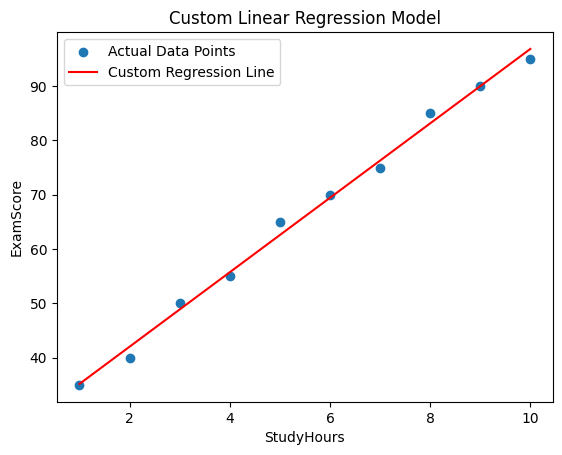

In [103]:
plt.scatter(x=df['StudyHours'], y=df['ExamScore'], label='Actual Data Points')
plt.plot(list(range(1,11)), [m * x + b for x in range(1,11)], color='red', label='Custom Regression Line')
plt.xlabel('StudyHours')
plt.ylabel('ExamScore')
plt.title('Custom Linear Regression Model')
plt.legend()
plt.show()

# Test on Another Dataset

In [104]:
# salary_df = pd.read_csv()
salary_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML projects/Linear Regression from scratch /Salary Data.csv")

In [105]:
salary_df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [106]:
salary_df.shape

(30, 2)

In [107]:
salary_df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [108]:
X = salary_df.drop(columns=['Salary'])
y = salary_df['Salary']

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [110]:
model.fit(X_train,y_train)


LinearRegression()

In [111]:
y_pred = model.predict(X_test)

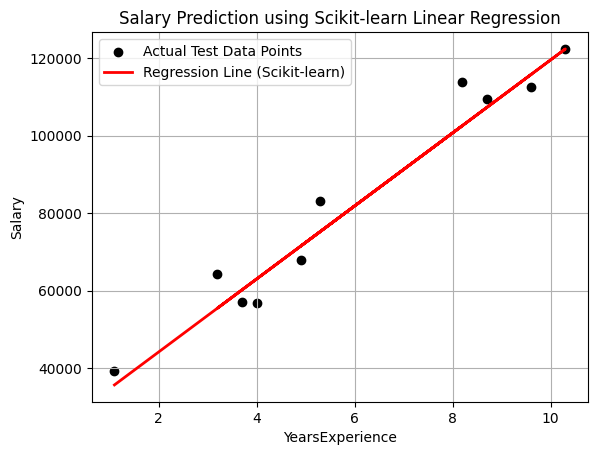

In [112]:
plt.scatter(X_test, y_test, color='black', label='Actual Test Data Points')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line (Scikit-learn)')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('Salary Prediction using Scikit-learn Linear Regression')
plt.grid(True)
plt.legend()
plt.show()

In [114]:
def loss_function(m,b,salary_df):
  total_cost = 0
  for i in range(len(salary_df)):
    x = salary_df.iloc[i].YearsExperience
    y = salary_df.iloc[i].Salary

    total_cost += (y - (m*x + b)) ** 2
  total_cost = total_cost / float(len(salary_df))
  return total_cost

In [119]:
def gradient_descent(m_now,b_now,df,lr):
  m_gradient = 0
  b_gradient = 0
  n = len(df)
  for i in range(n):

    x = salary_df.iloc[i].YearsExperience
    y = salary_df.iloc[i].Salary

    m_gradient += -(2/n) * (x * (y - (m_now*x + b_now)))
    b_gradient += -(2/n) *(y - (m_now*x + b_now))

  m = m_now - m_gradient * lr
  b = b_now - b_gradient * lr

  return m,b


In [120]:
from tqdm import tqdm
m = 0
b = 0
LR = 0.01
epoches = 30000
for i in tqdm(range(epoches)):
  m,b = gradient_descent(m,b,salary_df,LR)
print(m,b)

100%|██████████| 30000/30000 [00:57<00:00, 520.68it/s]

9449.962321455143 25792.20019866825


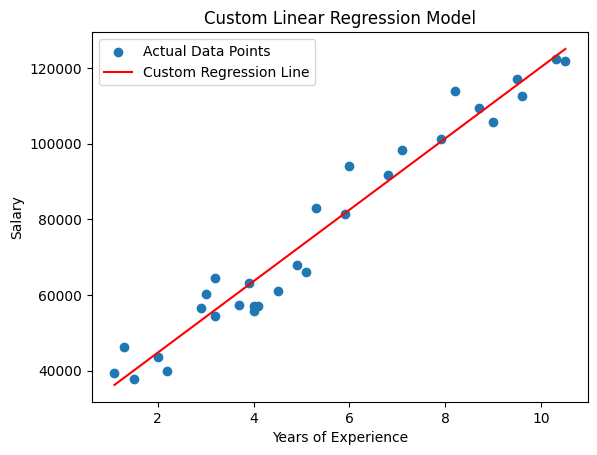

In [122]:
plt.scatter(x=salary_df['YearsExperience'], y=salary_df['Salary'], label='Actual Data Points')
plt.plot(salary_df['YearsExperience'], [m * x_val + b for x_val in salary_df['YearsExperience']], color='red', label='Custom Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Custom Linear Regression Model')
plt.legend()
plt.show()